In [1]:
pip install numpy pandas matplotlib seaborn scipy scikit-learn jupyter ipykernel

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import pandas as pd



In [3]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


In [5]:
df = pd.read_excel('RASFF_window_results.xlsx')

In [6]:
df.head

<bound method NDFrame.head of      reference               category  type  \
0    2026.2638  fruits and vegetables  food   
1    2026.2608  fruits and vegetables  food   
2    2026.2568  fruits and vegetables  food   
3    2026.2524  fruits and vegetables  food   
4    2026.2453  fruits and vegetables  food   
..         ...                    ...   ...   
897  2019.3017  fruits and vegetables  food   
898  2019.2995  fruits and vegetables  food   
899  2019.1793  fruits and vegetables  food   
900  2018.0976  fruits and vegetables  food   
901  2018.0945  fruits and vegetables  food   

                                               subject                 date  \
0    Unauthorised pesticides in grape leaves from S...  26-03-2026 16:16:33   
1    Unauthorised pesticides in grape leaves from t...  26-03-2026 12:39:48   
2    Too much pesticide residue (acetamiprid) in ch...  25-03-2026 16:08:15   
3              chlorfenapyr in Laiyang Pear from China  24-03-2026 15:18:30   
4    Aceta

In [7]:
print(df.shape)

(902, 14)


In [8]:
print(df['date'].min(), df['date'].max())

01-03-2022 14:00:27 31-12-2025 11:23:46


In [9]:
# Top origin countries
print(df['origin'].value_counts().head(15))

origin
Türkiye         223
India            82
Egypt            65
Poland           43
Spain            39
China            35
Italy            35
Thailand         29
Cambodia         21
Vietnam          19
Greece           16
Brazil           16
Morocco          14
Lebanon          12
South Africa     12
Name: count, dtype: int64


In [10]:
# Categories breakdown
print(df['category'].value_counts())

category
fruits and vegetables           665
herbs and spices                177
nuts, nut products and seeds     60
Name: count, dtype: int64


In [11]:
# Risk classification
print(df['classification'].value_counts())

classification
information notification for attention    483
alert notification                        270
information notification for follow-up    149
Name: count, dtype: int64


In [12]:
# Check if Kenya appears at all
print(df[df['origin'].str.contains('Kenya', na=False)])

     reference               category  type  \
305  2024.0957  fruits and vegetables  food   
366  2023.6144  fruits and vegetables  food   
373  2023.5643  fruits and vegetables  food   
426  2023.2896  fruits and vegetables  food   

                                               subject                 date  \
305   Dithiocarbamates in Basil from Kenya, via Israel  09-02-2024 16:03:40   
366    Chlorpyrifos in avocado from Kenya, via Germany  08-09-2023 15:15:59   
373  Chlorothalonil in sugar snap peas from Kenya v...  21-08-2023 16:17:56   
426  Chlorothalonil in thyme from Kenya, via the Ne...  03-05-2023 12:39:32   

    notifying_country                          classification  \
305           Belgium                      alert notification   
366           Czechia  information notification for attention   
373           Germany  information notification for attention   
426           Czechia  information notification for attention   

           risk_decision                  

In [13]:
east_africa = ['Kenya', 'Tanzania', 'Uganda', 'Ethiopia', 'Rwanda']
mask = df['origin'].str.contains('|'.join(east_africa), na=False)
print(df[mask]['origin'].value_counts())

origin
Kenya            4
Tanzania         3
Uganda           2
France,Uganda    1
Name: count, dtype: int64


In [14]:
# Check for missing values
print(df.isnull().sum())

reference              0
category               0
type                   0
subject                0
date                   0
notifying_country      0
classification         0
risk_decision          0
distribution           0
forAttention         215
forFollowUp          390
operator               0
origin                 0
hazards                0
dtype: int64


In [15]:
# Check date column type
print(df['date'].dtype)

object


In [16]:
# Fix date column
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Confirm it worked
print(df['date'].dtype)
print(df['year'].value_counts().sort_index())

datetime64[ns]
year
2018      2
2019     11
2020     66
2021    202
2022    157
2023    148
2024    127
2025    151
2026     38
Name: count, dtype: int64


In [17]:
# Drop columns we don't need
df_clean = df.drop(columns=['forAttention', 'forFollowUp', 'distribution'])

# Confirm clean shape
print(df_clean.shape)
print(df_clean.columns.tolist())

(902, 13)
['reference', 'category', 'type', 'subject', 'date', 'notifying_country', 'classification', 'risk_decision', 'operator', 'origin', 'hazards', 'year', 'month']


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

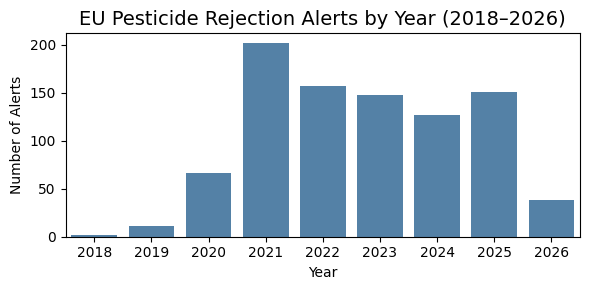

In [22]:
yearly = df_clean.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(6,3))
sns.barplot(data=yearly, x='year', y='count', color='steelblue')
plt.title('EU Pesticide Rejection Alerts by Year (2018–2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Alerts')
plt.tight_layout()
plt.savefig('rejections_by_year.png', dpi=150)
plt.show()


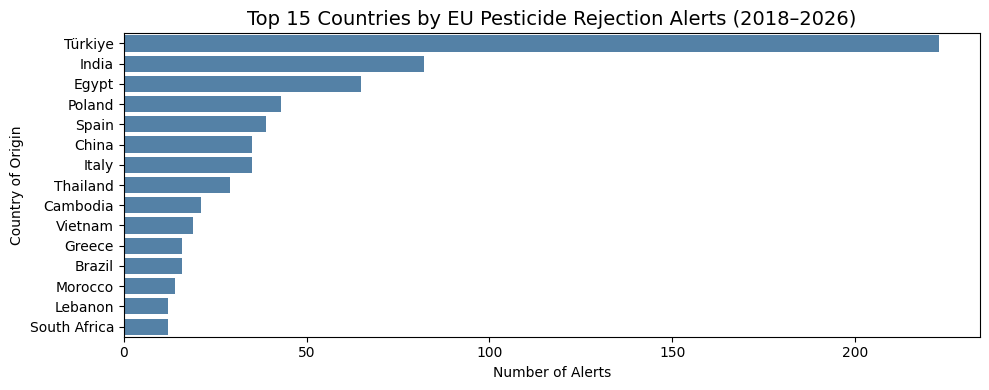

In [24]:
# Top 15 countries by rejection count
top_countries = df_clean['origin'].value_counts().head(15).reset_index()
top_countries.columns = ['country', 'count']

plt.figure(figsize=(10,4))
sns.barplot(data=top_countries, x='count', y='country', color='steelblue')
plt.title('Top 15 Countries by EU Pesticide Rejection Alerts (2018–2026)', fontsize=14)
plt.xlabel('Number of Alerts')
plt.ylabel('Country of Origin')
plt.tight_layout()
plt.savefig('rejections_by_country.png', dpi=150)
plt.show()

In [25]:
# Extract individual pesticides from hazards column
pesticides = df_clean['hazards'].str.extractall(r'([a-zA-Z][\w\s\-]+?)\s*(?:unauthorised substance|unauthorised)?\s*-\s*\{pesticide residues\}')
pesticide_counts = pesticides[0].str.strip().value_counts().head(15).reset_index()
pesticide_counts.columns = ['pesticide', 'count']

print(pesticide_counts)

              pesticide  count
0          chlorpyrifos    302
1   chlorpyrifos-methyl     84
2           acetamiprid     83
3           carbendazim     72
4        ethylene oxide     59
5         propiconazole     46
6    lambda-cyhalothrin     38
7          thiamethoxam     32
8            dimethoate     32
9          chlorfenapyr     28
10         imidacloprid     28
11         cypermethrin     25
12   pesticide residues     24
13   thiophanate-methyl     24
14           buprofezin     23


In [26]:
pesticide_counts = pesticide_counts[pesticide_counts['pesticide'] != 'pesticide residues']


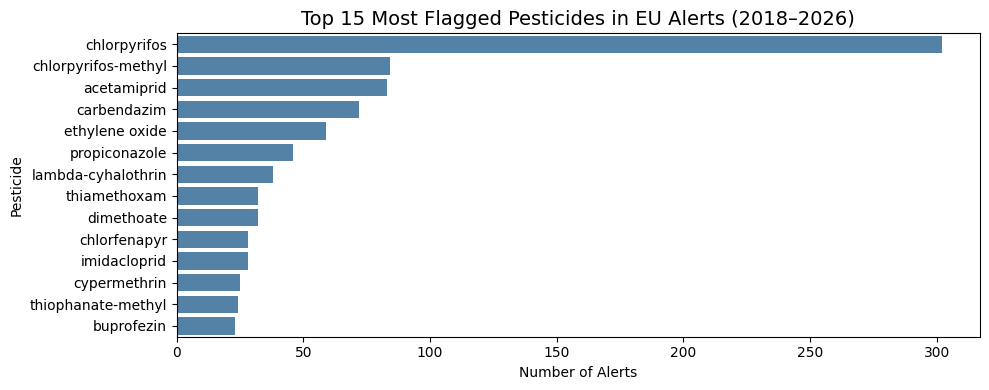

In [28]:
plt.figure(figsize=(10,4))
sns.barplot(data=pesticide_counts, x='count', y='pesticide', color='steelblue')
plt.title('Top 15 Most Flagged Pesticides in EU Alerts (2018–2026)', fontsize=14)
plt.xlabel('Number of Alerts')
plt.ylabel('Pesticide')
plt.tight_layout()
plt.savefig('top_pesticides.png', dpi=150)
plt.show()

In [29]:
# Get top 10 countries and top 10 pesticides
top10_countries = df_clean['origin'].value_counts().head(10).index.tolist()


In [30]:
# Explode pesticides into separate rows
df_clean['pesticide_clean'] = df_clean['hazards'].str.extractall(
    r'([a-zA-Z][\w\s\-]+?)\s*(?:unauthorised substance|unauthorised)?\s*-\s*\{pesticide residues\}'
).groupby(level=0)[0].apply(lambda x: x.str.strip().tolist())

df_exploded = df_clean.explode('pesticide_clean').dropna(subset=['pesticide_clean'])
df_exploded['pesticide_clean'] = df_exploded['pesticide_clean'].str.strip()

top10_pesticides = df_exploded['pesticide_clean'].value_counts().head(10).index.tolist()


In [31]:
# Filter and build heatmap matrix
heat_data = df_exploded[
    df_exploded['origin'].isin(top10_countries) & 
    df_exploded['pesticide_clean'].isin(top10_pesticides)
]

heat_matrix = heat_data.groupby(['origin', 'pesticide_clean']).size().unstack(fill_value=0)


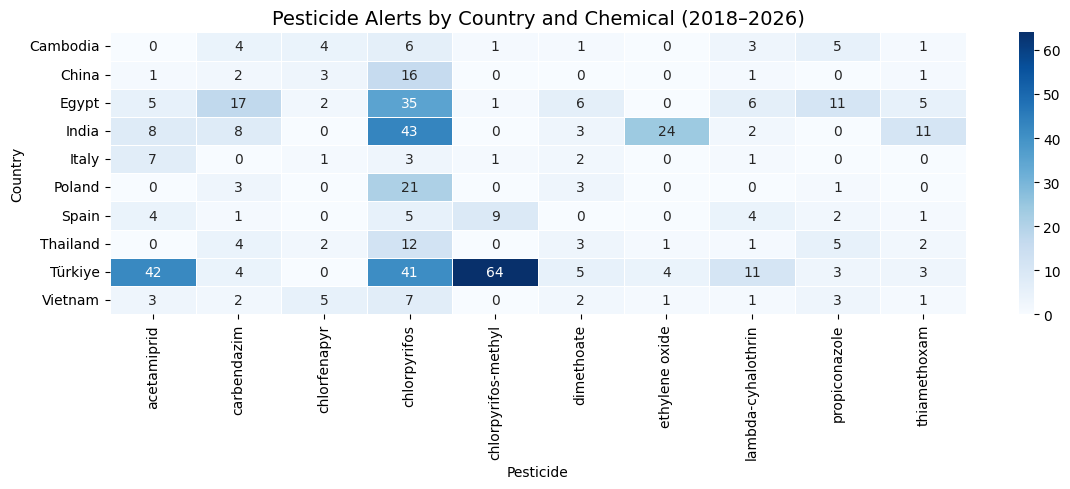

In [33]:
# Plot
plt.figure(figsize=(12,5))
sns.heatmap(heat_matrix, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Pesticide Alerts by Country and Chemical (2018–2026)', fontsize=14)
plt.xlabel('Pesticide')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('heatmap_country_pesticide.png', dpi=150)
plt.show()

In [35]:
## Kenya Implications
Kenya's 4 RASFF alerts involved chlorpyrifos (avocado) and 
chlorothalonil (sugar snap peas, thyme, basil) — chemicals that 
appear consistently across high-rejection countries in this dataset. 
Kenya's low alert count reflects low export volumes to the EU, 
not necessarily full compliance. As export volumes grow, 
these same chemicals pose significant rejection risk.

SyntaxError: unterminated string literal (detected at line 2) (1206787112.py, line 2)

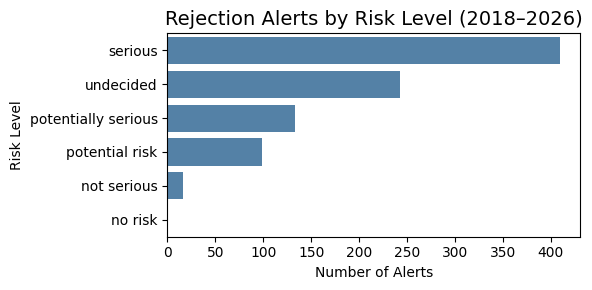

In [37]:
# Risk decision distribution
risk_counts = df_clean['risk_decision'].value_counts().reset_index()
risk_counts.columns = ['risk_level', 'count']

plt.figure(figsize=(6,3))
sns.barplot(data=risk_counts, x='count', y='risk_level', color='steelblue')
plt.title('Rejection Alerts by Risk Level (2018–2026)', fontsize=14)
plt.xlabel('Number of Alerts')
plt.ylabel('Risk Level')
plt.tight_layout()
plt.savefig('risk_levels.png', dpi=150)
plt.show()

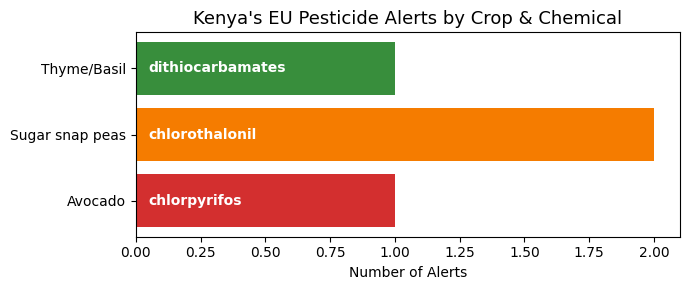

In [39]:
# Kenya specific
kenya_df = df_clean[df_clean['origin'].str.contains('Kenya', na=False)]

plt.figure(figsize=(7,3))
kenya_hazards = ['chlorpyrifos', 'chlorothalonil', 'dithiocarbamates']
kenya_crops = ['Avocado', 'Sugar snap peas', 'Thyme/Basil']
colors = ['#d32f2f', '#f57c00', '#388e3c']

plt.barh(kenya_crops, [1,2,1], color=colors)
plt.title("Kenya's EU Pesticide Alerts by Crop & Chemical", fontsize=13)
plt.xlabel('Number of Alerts')
for i, (h, c) in enumerate(zip(kenya_hazards, kenya_crops)):
    plt.text(0.05, i, h, va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('kenya_alerts.png', dpi=150)
plt.show()

In [4]:
# We build this directly in pandas — clean, citable, honest
mrl_data = {
    'crop': ['Avocado','Avocado','Avocado',
             'Green beans','Green beans','Green beans',
             'Snow peas','Snow peas','Snow peas',
             'Basil','Basil','Basil',
             'Chillies','Chillies','Chillies'],
    'pesticide': ['chlorpyrifos','chlorothalonil','carbendazim',
                  'chlorpyrifos','acetamiprid','dimethoate',
                  'chlorpyrifos','chlorothalonil','acetamiprid',
                  'dithiocarbamates','chlorpyrifos','acetamiprid',
                  'chlorpyrifos','acetamiprid','lambda-cyhalothrin'],
    'EU_MRL':  [0.01, 0.01, 0.1,
                0.01, 0.09, 0.02,
                0.01, 0.01, 0.09,
                0.01, 0.01, 0.09,
                0.5,  0.2,  0.1],
    'UK_MRL':  [0.01, 0.01, 0.1,
                0.01, 0.09, 0.02,
                0.01, 0.01, 0.09,
                0.01, 0.01, 0.09,
                0.5,  0.2,  0.1],
    'Gulf_MRL':[0.3,  0.1,  0.5,
                0.5,  0.5,  0.1,
                0.05, 0.1,  0.5,
                0.1,  0.05, 0.5,
                1.0,  0.5,  0.3],
    'source':  ['EU Reg 396/2005']*15
}

df_mrl = pd.DataFrame(mrl_data)
print(df_mrl)

           crop           pesticide  EU_MRL  UK_MRL  Gulf_MRL           source
0       Avocado        chlorpyrifos    0.01    0.01      0.30  EU Reg 396/2005
1       Avocado      chlorothalonil    0.01    0.01      0.10  EU Reg 396/2005
2       Avocado         carbendazim    0.10    0.10      0.50  EU Reg 396/2005
3   Green beans        chlorpyrifos    0.01    0.01      0.50  EU Reg 396/2005
4   Green beans         acetamiprid    0.09    0.09      0.50  EU Reg 396/2005
5   Green beans          dimethoate    0.02    0.02      0.10  EU Reg 396/2005
6     Snow peas        chlorpyrifos    0.01    0.01      0.05  EU Reg 396/2005
7     Snow peas      chlorothalonil    0.01    0.01      0.10  EU Reg 396/2005
8     Snow peas         acetamiprid    0.09    0.09      0.50  EU Reg 396/2005
9         Basil    dithiocarbamates    0.01    0.01      0.10  EU Reg 396/2005
10        Basil        chlorpyrifos    0.01    0.01      0.05  EU Reg 396/2005
11        Basil         acetamiprid    0.09    0.09 

In [5]:
def market_risk_check(crop, market='EU'):
    """
    Input: crop name + target market (EU, UK, Gulf)
    Output: risk table for that crop in that market
    """
    mrl_col = f'{market}_MRL'
    
    # Filter for the crop
    crop_data = df_mrl[df_mrl['crop'].str.lower() == crop.lower()].copy()
    
    if crop_data.empty:
        print(f"Crop '{crop}' not found. Available: {df_mrl['crop'].unique()}")
        return
    
    # Flag risk level
    def flag_risk(mrl):
        if mrl <= 0.01:
            return '🔴 HIGH'
        elif mrl <= 0.1:
            return '🟠 MEDIUM'
        else:
            return '🟢 LOW'
    
    crop_data['risk'] = crop_data[mrl_col].apply(flag_risk)
    crop_data['MRL_limit'] = crop_data[mrl_col]
    
    print(f"\n Crop: {crop} |  Market: {market}")
    print("="*55)
    print(crop_data[['pesticide','MRL_limit','risk']].to_string(index=False))

# Test it
market_risk_check('Avocado', 'EU')
market_risk_check('Green beans', 'Gulf')


 Crop: Avocado |  Market: EU
     pesticide  MRL_limit     risk
  chlorpyrifos       0.01   🔴 HIGH
chlorothalonil       0.01   🔴 HIGH
   carbendazim       0.10 🟠 MEDIUM

 Crop: Green beans |  Market: Gulf
   pesticide  MRL_limit     risk
chlorpyrifos        0.5    🟢 LOW
 acetamiprid        0.5    🟢 LOW
  dimethoate        0.1 🟠 MEDIUM


In [7]:
def compare_markets(crop):
    print(f"\n Market Comparison for: {crop}")
    print("="*65)
    for market in ['EU', 'UK', 'Gulf']:
        mrl_col = f'{market}_MRL'
        crop_data = df_mrl[df_mrl['crop'].str.lower() == crop.lower()].copy()
        if crop_data.empty:
            continue
        high_risk = crop_data[crop_data[mrl_col] <= 0.01]['pesticide'].tolist()
        print(f"{market:6} → 🔴 HIGH risk chemicals: {high_risk if high_risk else 'None'}")

compare_markets('Avocado')
compare_markets('Green beans')
compare_markets('Snow peas')


 Market Comparison for: Avocado
EU     → 🔴 HIGH risk chemicals: ['chlorpyrifos', 'chlorothalonil']
UK     → 🔴 HIGH risk chemicals: ['chlorpyrifos', 'chlorothalonil']
Gulf   → 🔴 HIGH risk chemicals: None

 Market Comparison for: Green beans
EU     → 🔴 HIGH risk chemicals: ['chlorpyrifos']
UK     → 🔴 HIGH risk chemicals: ['chlorpyrifos']
Gulf   → 🔴 HIGH risk chemicals: None

 Market Comparison for: Snow peas
EU     → 🔴 HIGH risk chemicals: ['chlorpyrifos', 'chlorothalonil']
UK     → 🔴 HIGH risk chemicals: ['chlorpyrifos', 'chlorothalonil']
Gulf   → 🔴 HIGH risk chemicals: None


In [ ]:
# Note: UK retained most EU MRL levels post-Brexit (2020)
# EU-UK gap is minimal for these chemicals
# The significant divergence is EU/UK vs Gulf (Codex standards)